In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.ensemble import RandomForestClassifier


data = pd.read_csv('processed.cleveland.data',names=['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','num'])
display(data)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [3]:
#preprocessing
data1=data[~(data == '?').any(axis=1)]
data1.loc[data1["num"] >= 1, "num"] = 1
display(data1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1


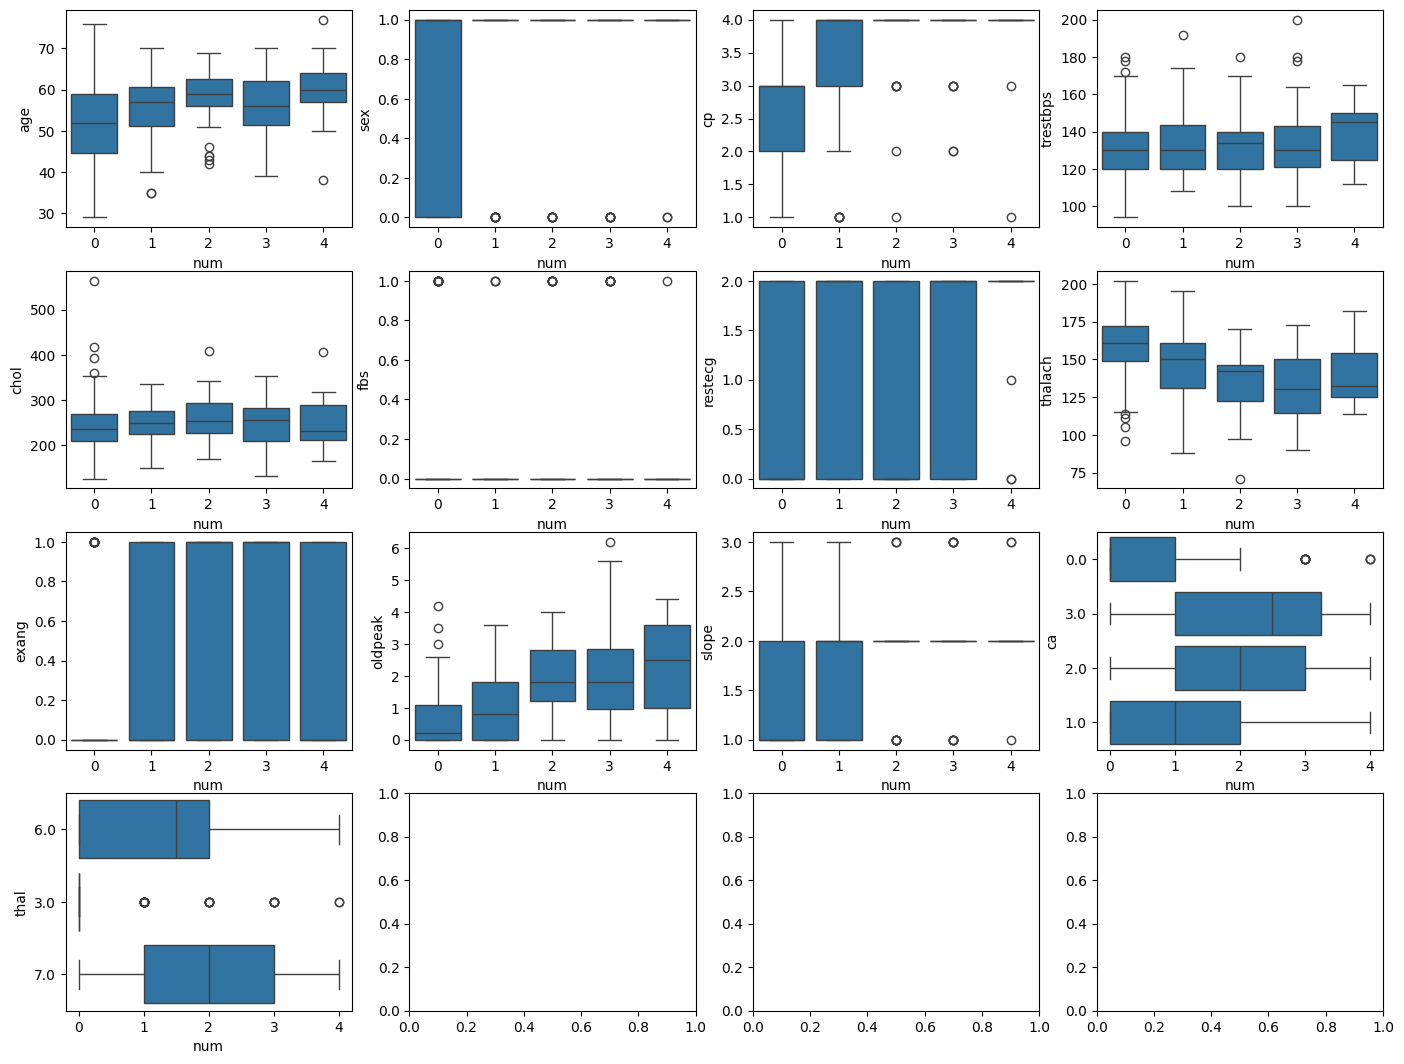

In [54]:
#EDA

#box plots
fig, axes = plt.subplots(4, 4, figsize=(17,13))
sns.boxplot(ax=axes[0,0],data=data1,x='num',y=data.columns[0])
sns.boxplot(ax=axes[0,1],data=data1,x='num',y=data.columns[1])
sns.boxplot(ax=axes[0,2],data=data1,x='num',y=data.columns[2])
sns.boxplot(ax=axes[0,3],data=data1,x='num',y=data.columns[3])
sns.boxplot(ax=axes[1,0],data=data1,x='num',y=data.columns[4])
sns.boxplot(ax=axes[1,1],data=data1,x='num',y=data.columns[5])
sns.boxplot(ax=axes[1,2],data=data1,x='num',y=data.columns[6])
sns.boxplot(ax=axes[1,3],data=data1,x='num',y=data.columns[7])
sns.boxplot(ax=axes[2,0],data=data1,x='num',y=data.columns[8])
sns.boxplot(ax=axes[2,1],data=data1,x='num',y=data.columns[9])
sns.boxplot(ax=axes[2,2],data=data1,x='num',y=data.columns[10])
sns.boxplot(ax=axes[2,3],data=data1,x='num',y=data.columns[11])
sns.boxplot(ax=axes[3,0],data=data1,x='num',y=data.columns[12])
plt.show()

In [55]:
#pie chart


In [56]:
#histogram

C:\Users\gupta\AppData\Local\Temp\ipykernel_6068\586728781.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data1.corr(), annot=True, cmap='coolwarm', linewidths=0.5)


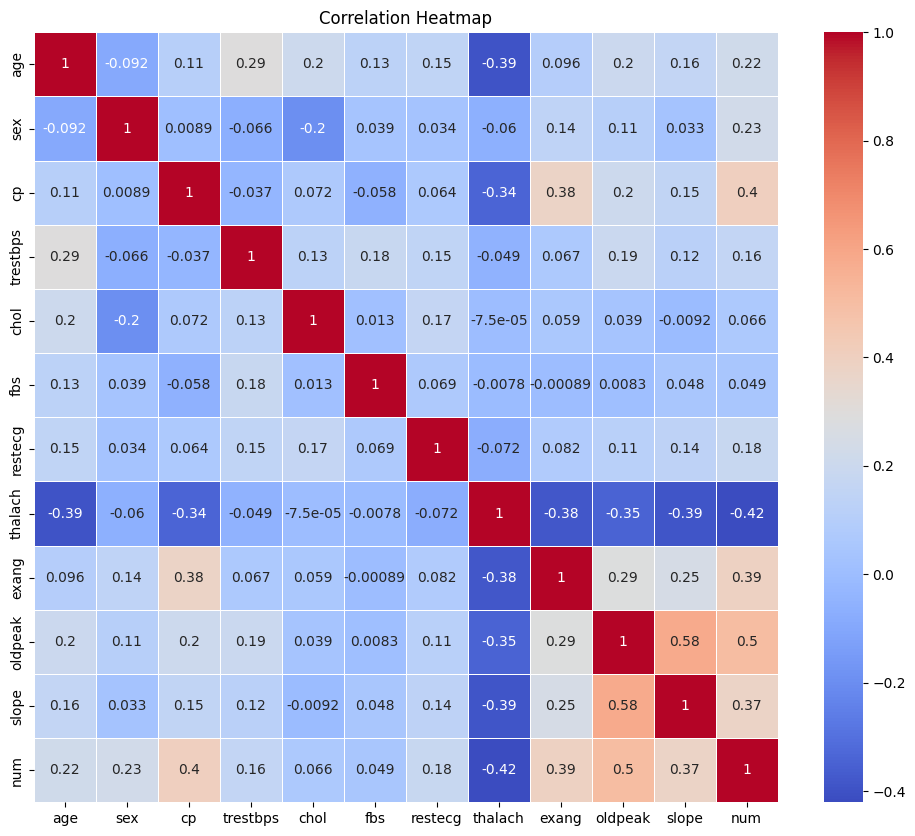

In [57]:
#heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(data1.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

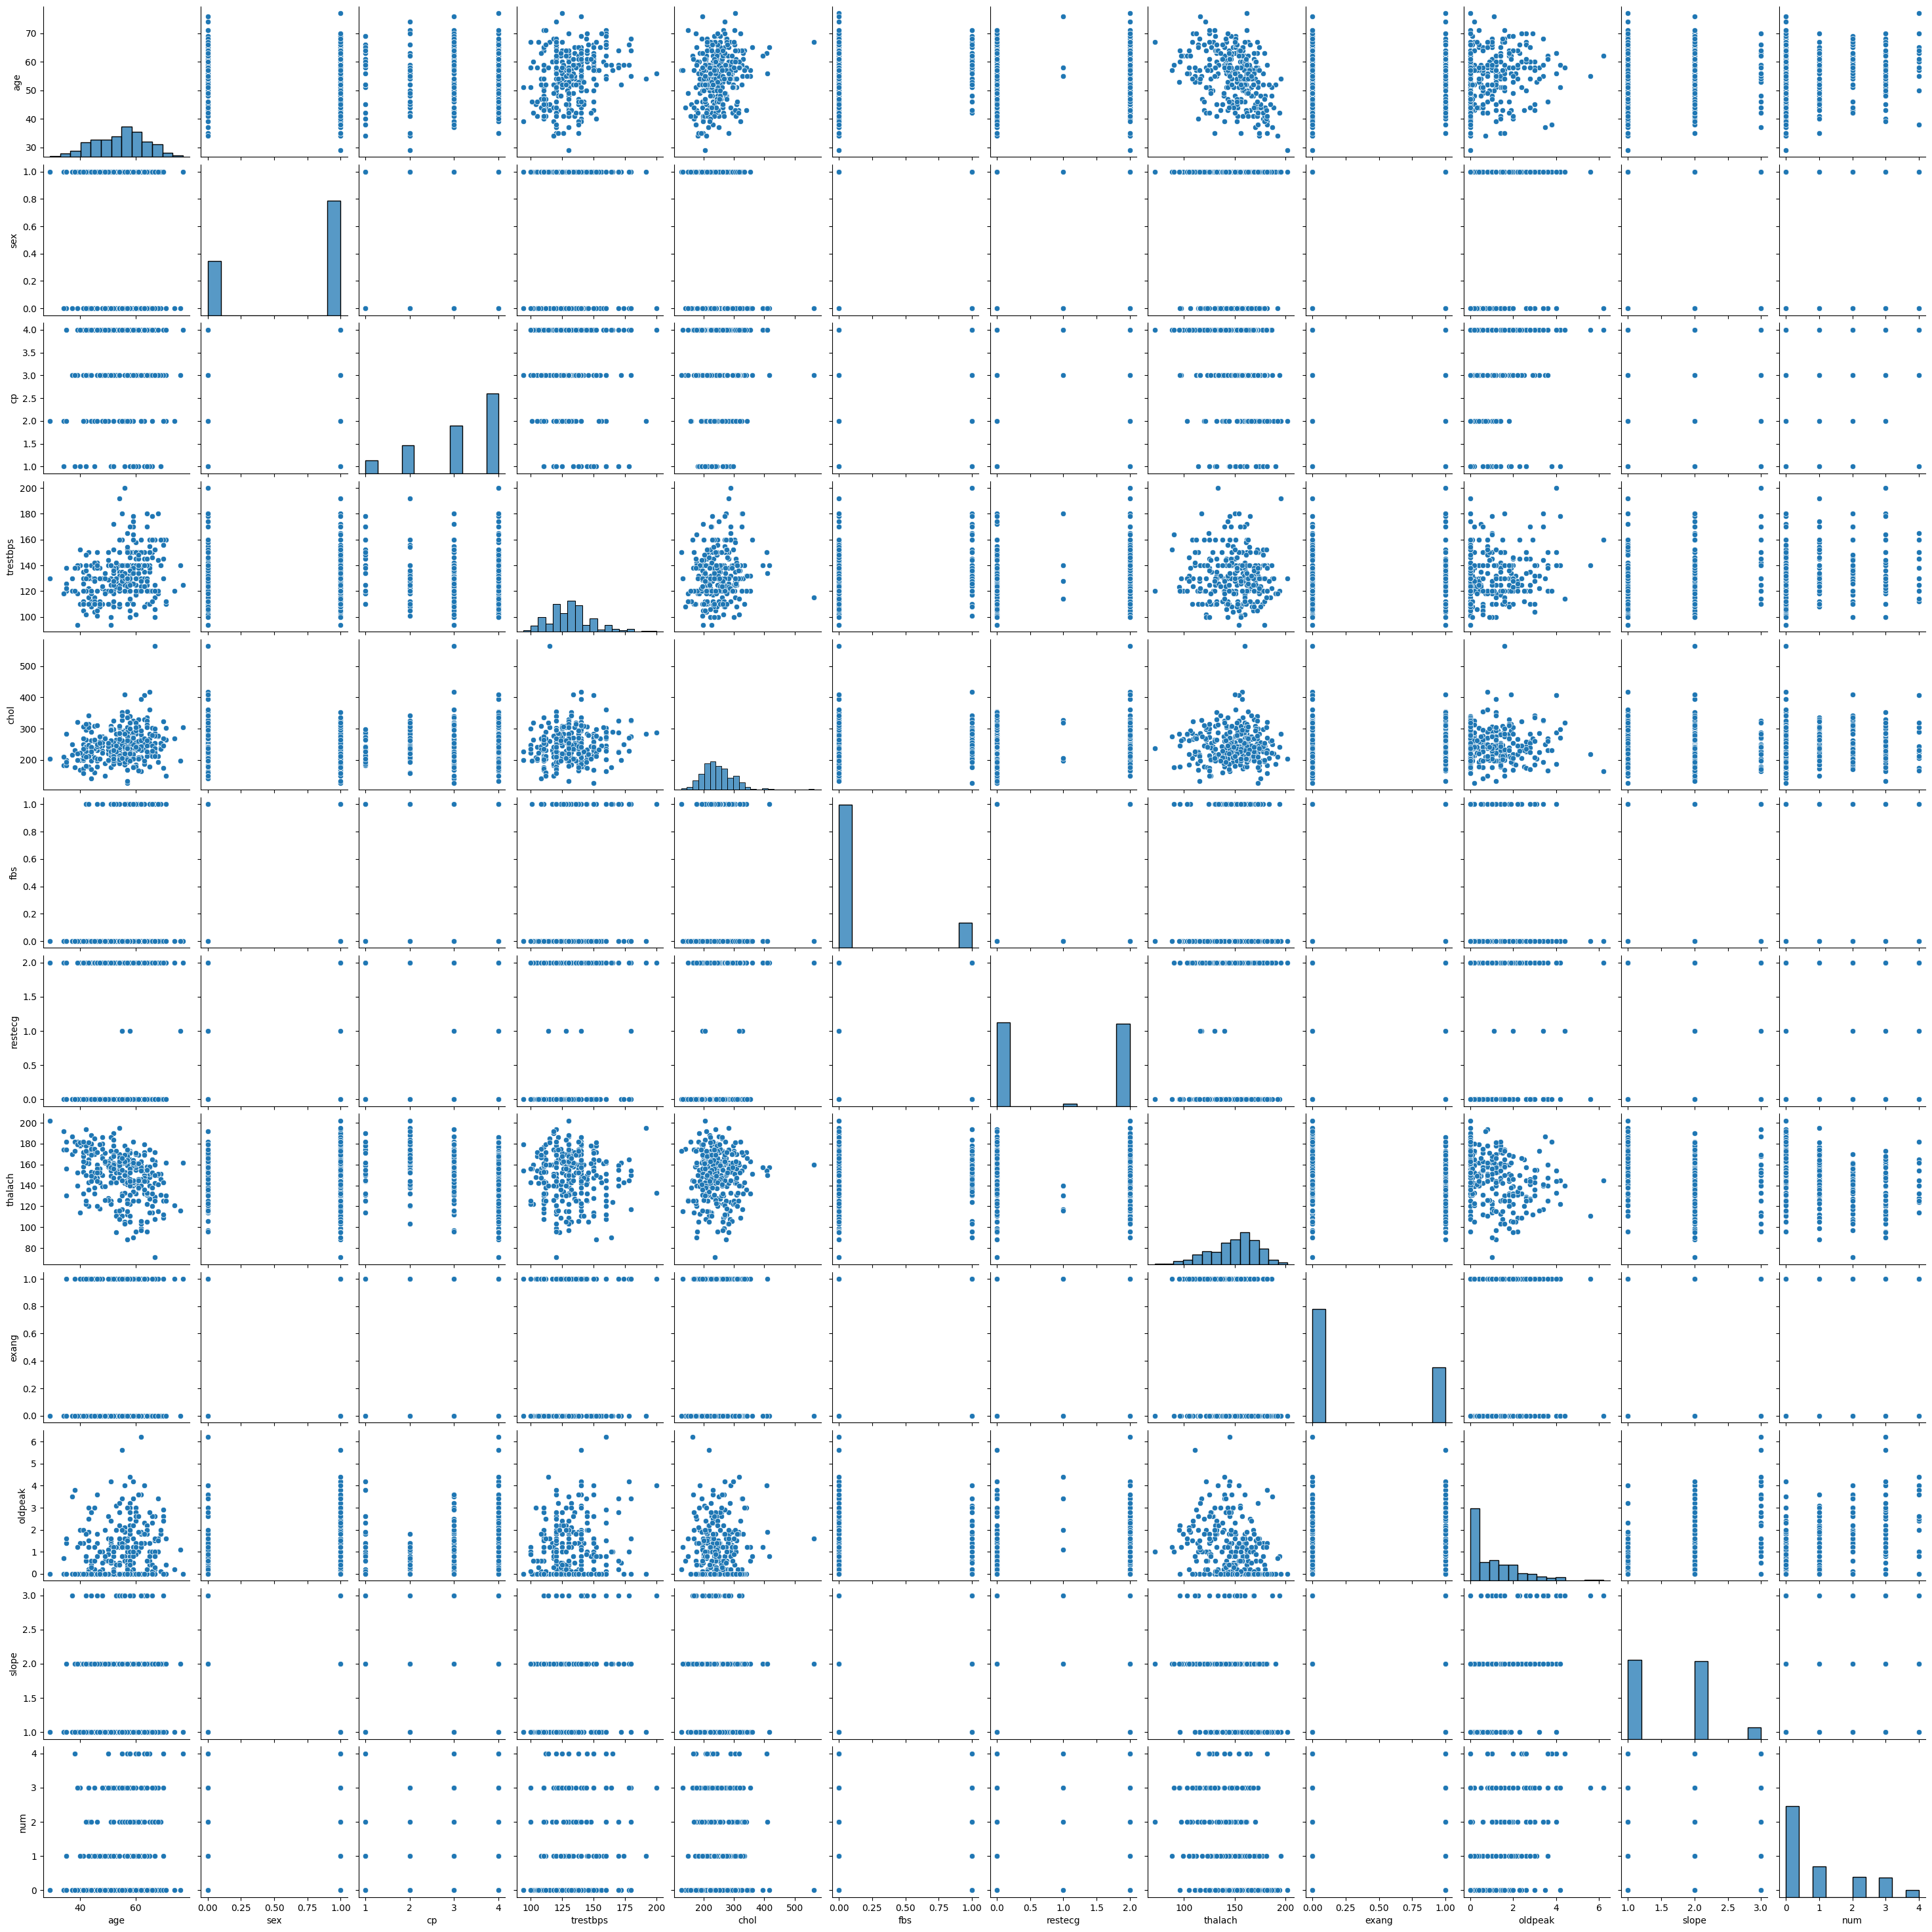

In [58]:
#pair plot
sns.pairplot(data)
plt.show()
# plt.savefig("pairplt.png")
# files.download("pairplt.png")

In [4]:
#splitting
X=data1.iloc[:,:-1]
y=data1.iloc[:,-1]
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2,random_state=0)
display(X)
display(y)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0


0      0
1      1
2      1
3      0
4      0
      ..
297    1
298    1
299    1
300    1
301    1
Name: num, Length: 297, dtype: int64

In [5]:
#decision tree
tree_entropy = DecisionTreeClassifier(criterion='entropy')
tree_gini = DecisionTreeClassifier(criterion='gini')

# Fit the classifiers on the training data
tree_entropy.fit(X_train, y_train)
tree_gini.fit(X_train, y_train)

# Predict using both classifiers
y_pred_entropy = tree_entropy.predict(X_test)
y_pred_gini = tree_gini.predict(X_test)

# Calculate accuracy scores for both classifiers
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
accuracy_gini = accuracy_score(y_test, y_pred_gini)

best_criterian='gini'
best_tree=DecisionTreeClassifier(criterion='gini')
if accuracy_entropy>accuracy_gini:
  best_criterian='entropy'
  best_tree=DecisionTreeClassifier(criterion='entropy')
print(f"Best criterion for attribute selection: {best_criterian} ")
print(f"Accuracy with the best criterion: {max(accuracy_entropy,accuracy_gini):.2f}")

Best criterion for attribute selection: gini 
Accuracy with the best criterion: 0.72


In [6]:
#hyper parameter tuning

param_grid = {
    'min_samples_split': [i for i in range(2,297)],
    'max_features': [i for i in range(1,14)]
}
# Initialize GridSearchCV
grid_search = GridSearchCV(best_tree, param_grid, scoring='accuracy',n_jobs=8,verbose=
                           3)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_min_samples_split = best_params['min_samples_split']
best_max_features = best_params['max_features']
print("best min samples split:",best_min_samples_split)
print("best max features:",best_max_features)


new_tree = DecisionTreeClassifier(criterion=best_criterian,min_samples_split=best_min_samples_split,max_features=best_max_features)
new_tree.fit(X_train, y_train)
y_pred_best = new_tree.predict(X_test)

# Calculate accuracy scores for both classifiers
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy with the best criterion: {best_accuracy:.2f}")


Fitting 5 folds for each of 3835 candidates, totalling 19175 fits
best min samples split: 25
best max features: 2
Accuracy with the best criterion: 0.82


In [7]:
rf_classifier = RandomForestClassifier()

# Define hyperparameters to search
param_grid = {
    'n_estimators': [10, 50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10,20,30]  # Minimum number of samples required to split a node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='accuracy',n_jobs=8)

# Perform the grid search
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']

# Initialize Random Forest with the best hyperparameters
best_rf_classifier = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split
)

# Fit the best classifier on the entire training set
best_rf_classifier.fit(X_train, y_train)

# Predict using the best classifier
y_pred_best = best_rf_classifier.predict(X_test)

# Calculate the classification report
classification_rep = classification_report(y_test, y_pred_best)

print("Best hyperparameters:")
print(f"n_estimators: {best_n_estimators}")
print(f"max_depth: {best_max_depth}")
print(f"min_samples_split: {best_min_samples_split}")
print("\nClassification Report:\n", classification_rep)

Best hyperparameters:
n_estimators: 100
max_depth: 30
min_samples_split: 10

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.90      0.83        30
           1       0.88      0.73      0.80        30

    accuracy                           0.82        60
   macro avg       0.83      0.82      0.82        60
weighted avg       0.83      0.82      0.82        60

